# Uncertainty estimate

In this notebook we find a measure of the accuracy of any admissions predictions we make from the derived coefficients. We do this by using the coefficients to calculate the admissions numbers in each MSOA, comparing the results with the real-life observed values, and measuring the typical difference between predicted and observed values.

We select groups of MSOAs that give roughly the same number of predicted stroke admissions. Their real-life observed admission numbers will naturally contain some variations from this predicted number. We expect that most MSOA have observed admissions quite close to the prediction and that others will be quite a bit larger or smaller. We can take the standard deviation of the observed admissions as a measure of the spread of values.

__Inputs__

+ MSOA-level admission numbers, numbers of people in each age band.
+ Probability of stroke given age band, i.e. SSNAP-derived coefficients
+ Total number of admissions in each age band from SSNAP
+ Best set of coefficients after nudging the values.

__Method__

Use the derived coefficients to calculate the admissions numbers for each MSOA.

Round the predicted admissions to the nearest whole number. Gather the MSOAs whose predicted admissions round to the same number.

To check the distribution of the observed admissions, plot a histogram of the observed admissions for each of these groups. The shape of the graph looks like a Poisson distribution, so overplot a normal distribution with the same mean and standard deviation as the observed admissions here. The normal distribution gives the best fit to the data for groups that contain at least 200 MSOAs.

Take the groups with at least 200 MSOAs. Collect their standard deviations. Fit a straight line to the standard deviation $s$ as a function of the predicted admissions $x$ to find $s = 0.13x + 1.30$.

Apply the standard deviation fit to all of the groups, including the ones with fewer than 200 MSOAs. Use this as a measure of the expected variation from the predicted values.

__Results__

The standard deviation $s$ of the observed admission values for a group of MSOA with predicted admissions $x$ is $s = 0.13x + 1.30$.

## Code setup

In [1]:
import polars as pl
import os
import numpy as np

# For plotting:
import matplotlib.pyplot as plt
import matplotlib.ticker  # for axis tick location

from scipy.stats import norm  # for normal distribution
import statsmodels.api as sm  # for ordinary least squares

## Load data

### Admissions

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [4]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}'
               for q in qmin_list for a in age_numbers]
# Check the first few:
print(coeff_names[:3])

# Quantile names:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))

['age_less65_q00', 'age_65_q00', 'age_70_q00']


Gather admissions data by deprivation quantile:

In [5]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Best coefficients

In [6]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

Pick out best set of coefficients:

In [7]:
df_best_coeffs = df_best_nudged.filter(df_best_nudged['fitness'] == df_best_nudged['fitness'].min())[0]

Convert to array:

In [8]:
best_coeffs = df_best_coeffs[coeff_names].to_numpy().flatten()

In [9]:
best_coeffs.reshape(5, 5)

array([[0.0006, 0.005 , 0.005 , 0.007 , 0.012 ],
       [0.0005, 0.003 , 0.004 , 0.007 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.005 , 0.011 ],
       [0.0003, 0.002 , 0.002 , 0.005 , 0.011 ]])

## Recalculate admissions

The usual function to calculate admissions:

In [10]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

Calculate the admissions using that function:

In [11]:
# Predictions for each MSOA:
predictions_lists = []
for i in range(5):
    coeffs = best_coeffs[(i*5):(i*5)+5]  # coeffs for this depriv.
    yhat = predict_admissions(x_lists[i], coeffs)
    # Difference from actual:
    predictions_lists.append(yhat)
    
# Combine lists:
observed_all = sum(admissions_lists, [])
predicted_all = sum(predictions_lists, [])

Compare the observed (real data) with the predicted (using the coefficients) admissions:

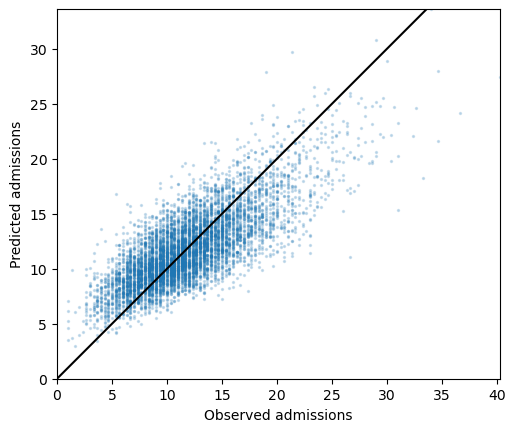

In [12]:
fig, ax = plt.subplots()

ax.scatter(observed_all, predicted_all, s=2, alpha=0.2)
ax.plot([0, max(observed_all)], [0, max(observed_all)], color='k')

ax.set_aspect('equal')
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Predicted admissions')

ax.set_xlim(0, max(observed_all))
ax.set_ylim(0, max(predicted_all))
plt.show()

## Slice bins

Set up the bins. Make them so that values will be grouped to their nearest whole number, e.g. the 13 bin will contain MSOA with predicted admissions numbers from 12.5 (inclusive) to 13.5 (exclusive) admissions.

In [13]:
# Set up bins with left/right edges between every whole number,
# so the bin middle values are all whole numbers from 0 to
# the number required so that every MSOA has a home:
bins = np.arange(-0.5, np.ceil(max(predicted_all))+0.5, 1.0)
bin_mids = bins + 0.5

# View bins:
bins

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5])

Use `digitize` to work out which bin each MSOA belongs to. Then make separate lists for each bin to group the MSOA data. Make a list for each group of MSOA's predicted and observed admissions numbers.

In [14]:
# Find which bin each value of predicted admissions belongs in.
# The index of each selected bin (its position in the list) is stored
# in bin_inds.
bin_inds = np.digitize(predicted_all, bins)
# In this list, bin index 0 will be for under -0.5 admissions (which
# shouldn't happen here!). Bin index 1 is for -0.5 (inclusive) to +0.5
# (exclusive).

# Store results as dict of lists:
binned_admissions = {}
binned_predictions = {}
# For each bin in turn, gather the values that belong in it.
for b, bin_left in enumerate(bins):
    # What is the middle of this bin?
    bin_mid = bin_mids[b]
    # Which items in the lists belong in this bin?
    # Add 1 because the first bin (when b=0) is labelled with
    # index 1 in bin_inds.
    p = np.where(bin_inds == b+1)
    # Pick out those items into their own separate list
    # and add them to the dictionary:
    binned_admissions[bin_mid] = np.array(observed_all)[p]
    binned_predictions[bin_mid] = np.array(predicted_all)[p]

Calculate useful statistics for each group. Find its mean, standard deviation, and the number of MSOA in the group.

In [15]:
# Place the results in this dictionary:
dict_stats = dict(
    bin_mids = [],
    means = [],
    stds = [],
    lengths = [],
)
# Calculate stats and place in the dictionary:
for bin_mid, admissions in binned_admissions.items():
    dict_stats['bin_mids'].append(bin_mid)
    dict_stats['means'].append(np.mean(admissions))
    dict_stats['stds'].append(np.std(admissions))
    dict_stats['lengths'].append(len(admissions))

# Convert the dictionary to a DataFrame:
df_bin_stats = pl.DataFrame()
for col, vals in dict_stats.items():
    df_bin_stats = df_bin_stats.with_columns(pl.Series(col, vals))

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  

View the results:

In [16]:
with pl.Config(set_tbl_rows=len(df_bin_stats)):
    display(df_bin_stats)

bin_mids,means,stds,lengths
f64,f64,f64,i64
0.0,NaN,NaN,0
1.0,NaN,NaN,0
2.0,NaN,NaN,0
3.0,2.111111,1.133115,3
4.0,3.583333,1.440968,8
5.0,4.292929,1.592824,33
6.0,5.622419,1.871225,113
7.0,6.76378,2.103037,254
8.0,8.010818,2.464692,493


Bins that are empty have NaN (Not A Number) means and stds.

Generally the means are quite a good match to the predicted admissions bin middles. The match is closer for the bins in the middle of the list than for the ones near the start or end.

Plot the means and standard deviations over the original scatter plot. The horizontal lines show where the edges of the bins are, so all scatter points between two adjacent lines are placed into the same bin because they are said to have the same predicted admissions number when rounded.

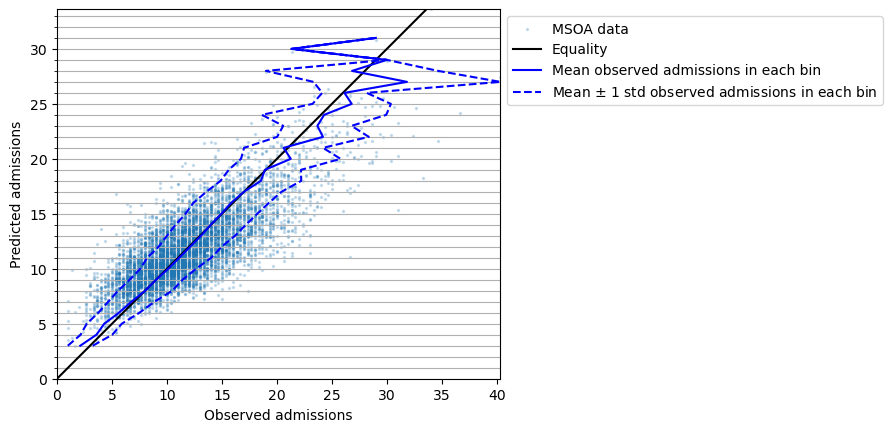

In [17]:
fig, ax = plt.subplots()

# Scatter admissions as usual:
ax.scatter(observed_all, predicted_all, s=2, alpha=0.2, label='MSOA data')
# Equality line:
ax.plot([0, max(observed_all)], [0, max(observed_all)],
        color='k', label='Equality')
# Plot mean +- std as lines:
ax.plot(df_bin_stats['means'], df_bin_stats['bin_mids'],
        color='b', label='Mean observed admissions in each bin')
ax.plot(df_bin_stats['means'] + df_bin_stats['stds'], df_bin_stats['bin_mids'],
        linestyle='--', color='b',
        label=r'Mean $\pm$ 1 std observed admissions in each bin')
ax.plot(df_bin_stats['means'] - df_bin_stats['stds'], df_bin_stats['bin_mids'],
        linestyle='--', color='b', label=None)

# Set axis limits and make it square:
ax.set_aspect('equal')
ax.set_xlim(0, max(observed_all))
ax.set_ylim(0, max(predicted_all))
# Add a grid to help pick out where the bins are:
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.grid(axis='y', which='both')

# Labels:
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Predicted admissions')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.show()

The mean line (solid blue) follows the equality line (predicted exactly equal to observed admissions) quite well when the predicted admissinos are around 8 to 17. Above and below this range the mean is more erratic, likely because there are fewer data points in those areas.

It looks like the std lines are spaced more closely to the mean line for smaller predicted admissions (lower down on the chart) than they are for larger predicted admissions (higher up).

Next, take a closer look at the distribution of observed admissions in each bin. In the following figure, plot a bar chart of the values in each bin that has at least 5 admissions. This cutoff will remove the more erratic areas of the above chart - it means we will only plot bins with predicted admissions from 4 to 26 inclusive.

On top of each bar chart we also plot a normal distribution with the same mean and standard deviation as the values in the bin. The normal distribution has more values near the mean and fewer values that are much larger or smaller than the mean, like we expect to see in the admissions data.

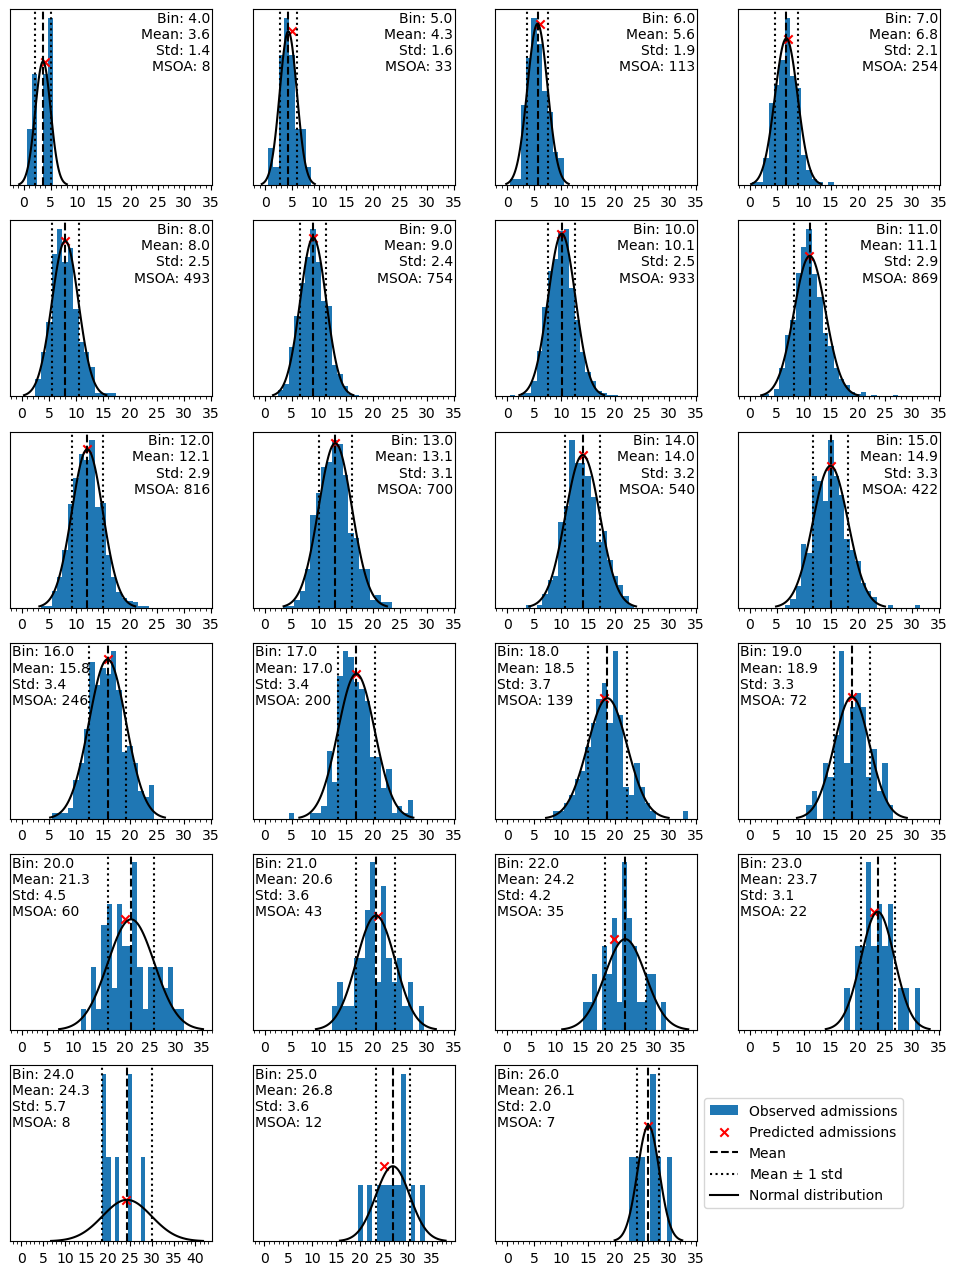

In [18]:
fig, axs = plt.subplots(6, 4, figsize=(12, 16))

# Only use bins that contain at least 5 MSOA:
df = df_bin_stats.filter(df_bin_stats['lengths'] >= 5)
# Plot each bin in turn:
for i in range(len(df)):
    # Select next available axis:
    ax = axs[i // 4, i % 4,]
    # Pick out data:
    b = df['bin_mids'][i]
    loc = df['means'][i]
    scale = df['stds'][i]
    admissions_here = binned_admissions[b]


    # Create normal distribution coordinates:
    norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=scale),
                         norm.ppf(0.999, loc=loc, scale=scale), 100)
    norm_y = norm.pdf(norm_x, loc=loc, scale=scale)

    # Bar chart:
    ax.hist(admissions_here, bins=bins, density=True, label='Observed admissions')
    # Mark expected mean:
    ax.scatter(b, max(norm_y), marker='x', color='r', linestyle='-', label='Predicted admissions')
    # Mark one standard deviation from the mean:
    ax.axvline(loc, color='k', linestyle='--', label='Mean')
    ax.axvline(loc + scale, color='k', linestyle=':', label=r'Mean $\pm$ 1 std')
    ax.axvline(loc - scale, color='k', linestyle=':', label=None)
    # Normal dist:
    ax.plot(norm_x, norm_y, color='k', label='Normal distribution')

    # Remove y ticks and labels.
    ax.set_yticks([])
    # Mark bin edges:
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))

    # Label each plot with the mean and std of the normal dist
    # as well as how many MSOA are in the bin.
    label = f'Bin: {b}' + '\n' + f'Mean: {loc:.1f}' + '\n' + f'Std: {scale:.1f}' + '\n' + f'MSOA: {df["lengths"][i]}'
    # Draw the label on either the top left or the top right
    # depending on where there's room:
    if i < 12:
        ax.annotate(label, xy=(0.99, 0.99), va='top', ha='right', xycoords='axes fraction')
    else:
        ax.annotate(label, xy=(0.01, 0.99), va='top', ha='left', xycoords='axes fraction')
    
    # If this is the last graph then draw the legend in the
    # gap left by the empty axis.
    if i == 22:
        ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])

# Remove the unwanted final axis:
axs[-1, -1].set_visible(False)

plt.show()

From the above histograms, see that the data fits best to the normal distribution when where are at least 200 MSOA in the sample. These ones consistently have a good match between the predicted admissions integer (red cross) and the top centre of the curve (solid line). This means that the mean of the observed admissions is close to the predicted admissions bin centre.

The good fits to the normal distribution suggest that the observed admissions follow a Poisson distribution with the same mean and std as the normal distributions.

We can use the bins where the normal distribution matches well to find a general trend of standard deviation size with predicted admissions. This will let us define a new model mean and standard deviation for the bins where currently the fit is poor.

## Mean-std fit

From the scatter plot above, we expect that the standard deviation size should increase with the predicted admissions. This means that we can first try to fit an Ordinary Least Squares (OLS) linear regression to the data. Graphically this is finding the best straight line that predicts standard deviation given only the bin number.

To find the best model, use only the bins with at least 200 MSOAs:

In [19]:
df_ols = df_bin_stats.filter(df_bin_stats['lengths'] >= 200)

View the range of bins used:

In [20]:
print(df_ols['bin_mids'].min(), df_ols['bin_mids'].max())

7.0 17.0


Link the means and stds using Ordinary Least Squares fit:

In [21]:
# Value we're predicting:
Y = df_ols['stds'].to_numpy()
# Value we know:
X = df_ols['bin_mids'].to_numpy()
# Allow a constant so fit is of form "y = mx + c".
X = sm.add_constant(X)

# Fit the data to the model:
model = sm.OLS(Y,X)
results = model.fit()

View the resulting model parameters:

In [22]:
ols_m = results.params[1]
ols_c = results.params[0]

print(f'Gradient:    {ols_m:.4f}')
print(f'y-intercept: {ols_c:.4f}')

Gradient:    0.1319
y-intercept: 1.2986


The formula of the straight line is:

In [23]:
fit_label = f'y = {ols_m:.2f}x + {ols_c:.2f}'

fit_label

'y = 0.13x + 1.30'

Plot the variation of standard deviation with mean in the data. Also include the straight line fit to the data.

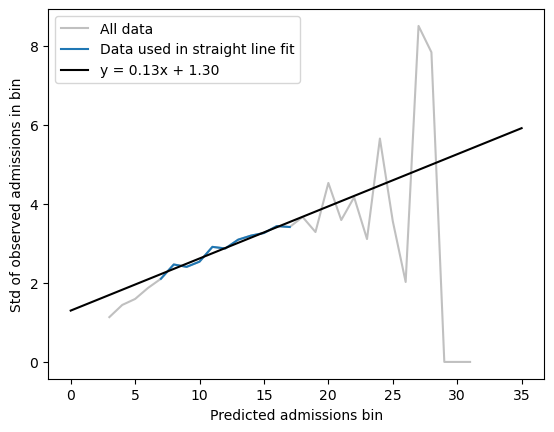

In [24]:
# Create coordinates for the straight line fit:
x = np.linspace(0, np.nanmax(df_bin_stats['bin_mids'])+1, 100)
y = ols_m*x + ols_c

fig, ax = plt.subplots()
# Display all bins in the background:
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['stds'], color='silver', label='All data')
# Display only the bins used in the fit more prominently:
ax.plot(df_ols['bin_mids'], df_ols['stds'], label='Data used in straight line fit')
# Draw the straight line fit of mean to std:
ax.plot(x, y, color='k', label=fit_label)

ax.set_xlabel('Predicted admissions bin')
ax.set_ylabel('Std of observed admissions in bin')
ax.legend()

plt.show()

The straight line fit is a good match to the data for the bins with at least 200 MSOA.

## Generate model standard deviations

Use the formula above with the predicted admissions bins to estimate the std for each bin.

In [25]:
# Calculate new standard deviations:
binned_stds_model = ols_m * df_bin_stats['bin_mids'] + ols_c

# Place it in the same dataframe as earlier:
df_bin_stats = df_bin_stats.with_columns(pl.Series('std_model', binned_stds_model))

View the results:

In [26]:
with pl.Config(set_tbl_rows=len(df_bin_stats)):
    display(df_bin_stats)

bin_mids,means,stds,lengths,std_model
f64,f64,f64,i64,f64
0.0,NaN,NaN,0,1.298589
1.0,NaN,NaN,0,1.430443
2.0,NaN,NaN,0,1.562298
3.0,2.111111,1.133115,3,1.694152
4.0,3.583333,1.440968,8,1.826007
5.0,4.292929,1.592824,33,1.957861
6.0,5.622419,1.871225,113,2.089715
7.0,6.76378,2.103037,254,2.22157
8.0,8.010818,2.464692,493,2.353424


Plot new fitted standard deviations over the predicted-observed admissions scatter:

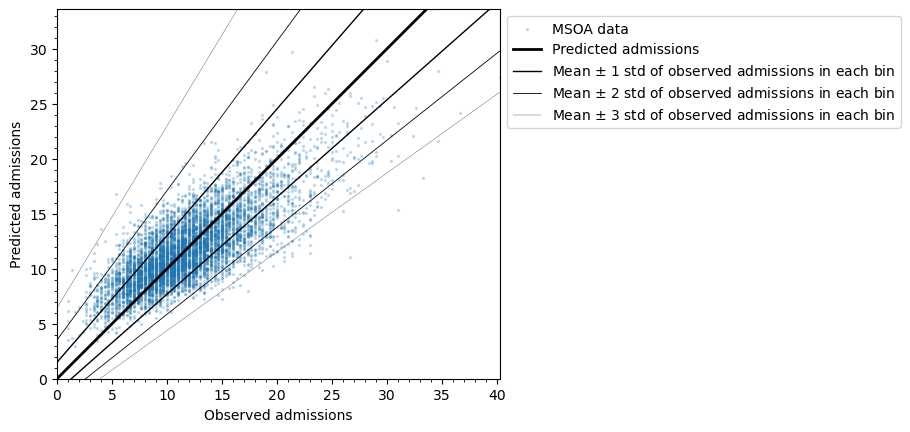

In [30]:
fig, ax = plt.subplots()

# Admissions data:
ax.scatter(observed_all, predicted_all, s=2, alpha=0.2, label='MSOA data')
# Equality line:
# ax.plot([0, max(observed_all)], [0, max(observed_all)], color='k', label='Equality')
# Mean +- std fit:
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['bin_mids'],
        color='k', label='Predicted admissions', linewidth=2)

linewidths = [1.0, 0.6, 0.2]
for i, m in enumerate(range(1, 4)):
    ax.plot(
        df_bin_stats['bin_mids'] + m * df_bin_stats['std_model'],
        df_bin_stats['bin_mids'],
        linewidth=linewidths[i],
        color='k',
        label=r'Mean $\pm$ ' + f'{m:.0f}' + ' std of observed admissions in each bin',
    )
    ax.plot(
        df_bin_stats['bin_mids'] - m * df_bin_stats['std_model'],
        df_bin_stats['bin_mids'],
        linewidth=linewidths[i],
        color='k',
    )
 
# Set axis limits and make it square:
ax.set_aspect('equal')
ax.set_xlim(0, max(observed_all))
ax.set_ylim(0, max(predicted_all))
# Add a grid to help pick out where the bins are:
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
# ax.grid(axis='y', which='both')

# Labels:
ax.set_xlabel('Observed admissions')
ax.set_ylabel('Predicted admissions')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.show()

Allowing two standard deviations either side of the mean (horizontally left or right from the central line) does cover most of the points.

## Conclusion

We can use this fitted standard deviation format as a measure of accuracy. For predicted admissions $x$, the std $s$ is $s = 0.13x + 1.30$ so the size of the standard deviation increases with the number of predicted admissions.

For generating admissions numbers with some variation from the single predicted value, we can sample a Poisson distribution with a mean of the predicted admissions and a standard deviation from the formula.